In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
ATAC_path = Path('data') / 'ImmGenATAC18_AllOCRsInfo.csv'
ATAC_data = pd.read_csv(ATAC_path)
ATAC_data #head: zeigt nur erste 5 Zeilen --> trotzdem alles geladen

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,ImmGenATAC1219.peak_1,chr1,3020786,0.00,0.56,NaN,NaN,NaN,0.41,0.71,...,0.10,0.10,3.19,1.37,0.52,1.27,0.10,0.57,3.27,1.41
1,ImmGenATAC1219.peak_2,chr1,3087226,0.00,0.50,NaN,NaN,NaN,0.41,1.64,...,1.70,0.10,1.41,0.47,0.11,0.92,0.98,2.16,2.34,0.94
2,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,2.36,0.10,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
3,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.41,0.10,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
4,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.41,0.10,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512590,ImmGenATAC1219.peak_512591,chrY,90812450,0.00,3.99,1.0,NaN,Erdr1,4.37,8.79,...,3.81,3.34,4.27,6.73,5.53,7.21,5.96,5.17,6.53,6.11
512591,ImmGenATAC1219.peak_512592,chrY,90812906,0.00,3.21,1.0,NaN,Erdr1,0.41,7.41,...,4.28,5.55,4.15,6.88,7.16,6.21,8.75,6.83,8.14,4.64
512592,ImmGenATAC1219.peak_512593,chrY,90813175,0.00,0.69,NaN,NaN,Erdr1,0.41,0.71,...,0.44,1.38,1.20,1.37,1.82,1.61,1.29,0.14,1.23,0.50
512593,ImmGenATAC1219.peak_512594,chrY,90813624,0.00,0.60,NaN,NaN,Erdr1,0.41,1.64,...,0.77,0.97,0.11,1.39,1.39,0.50,0.10,0.14,1.05,0.11


## <h1>ATAC_seq: Data Cleanup

<h3>Removing or imputing missing values</h3>

In [2]:
#number of rows
ATAC_data.__len__() 

512595

In [3]:
#number of missing data points per column
missing_values_count = ATAC_data.isnull().sum()
missing_values_count[missing_values_count > 0] #just show columes where data is missing

Included.in.systematic.analysis    177716
TSS                                498303
genes.within.100Kb                  84885
dtype: int64

**Data is missing in 3 columes**: Included.in.systematic.analysis, TSS, genes.within.100Kb  

**included in systematic analysis**: Boolean / yes-no flag indicating whether the authors considered this OCR reliable enough for downstream analyses in the paper
--> NaN: Yoshida et al. do not considerd it reliabale enough for further analysis and did't includ it in further analysis 

**TSS**: name of closest TSS gene
--> NaN: there isn't any TSS gene close to the peak

**genes within 100kb**: just lists all the genes in that range as str
--> NaN: If the peaks are not near any genes within 100 kb

In [4]:
# Wie viel prozent der cells sind missing values
total_cells = np.prod(ATAC_data.shape)
total_missing = missing_values_count.sum()

percent_missing = (total_missing/total_cells) * 100
percent_missing

np.float64(1.5147097670894654)

In [5]:
#values of TSS that are not NaN
just_TSS = ATAC_data.loc[~ATAC_data ["TSS"].isnull(), "TSS"]
just_TSS

20           Xkr4
139        Mrpl15
145        Lypla1
157         Tcea1
159         Tcea1
           ...   
512467      Vamp7
512477      Tmlhe
512506    Eif2s3y
512522        Uty
512532      Ddx3y
Name: TSS, Length: 14292, dtype: str

In [6]:
#Wie viele prozent cells missing in TSS (enhancer)
TSS_total_missing = ATAC_data ["TSS"]. isnull().sum()
TSS_total_cells = len(ATAC_data)
print(ATAC_data ["TSS"]. notnull().sum())

percent_missing_TSS = (TSS_total_missing/TSS_total_cells) * 100
print(percent_missing_TSS)

14292
97.21183390395926


es fehlen **97%** der werte in TSS --> weil diese nicht in der Nähe einer TSS sind --> distal enahncers

In [7]:
#values of Included.in.systematic.analysis	 that are not NaN
ATAC_data["Included.in.systematic.analysis"].notnull().sum()

just_Incl_sa = ATAC_data.loc[ATAC_data["Included.in.systematic.analysis"].notnull(),"Included.in.systematic.analysis"]
just_Incl_sa

2         1.0
3         1.0
5         1.0
6         1.0
7         1.0
         ... 
512587    1.0
512588    1.0
512589    1.0
512590    1.0
512591    1.0
Name: Included.in.systematic.analysis, Length: 334879, dtype: float64

**Rauswerfen Daten nicht reliabel Sysematic analysis of paper**
--> also included in systematic analysis = NaN

<h3>P-value filtering</h3>

In [8]:
Minimum_pvalues = ATAC_data["_-log10_bestPvalue"].min()
ATAC_data.sort_values(by=["_-log10_bestPvalue"])

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
64295,ImmGenATAC1219.peak_64296,chr10,122421608,0.00,0.00,NaN,NaN,Avpr1a,0.41,0.10,...,0.10,0.10,0.11,0.11,0.11,0.11,0.34,0.11,0.11,0.11
508409,ImmGenATAC1219.peak_508410,chrX,106733598,0.00,0.00,NaN,NaN,NaN,0.41,0.10,...,0.10,0.29,0.11,0.47,0.52,0.14,0.10,0.11,0.51,0.11
506621,ImmGenATAC1219.peak_506622,chrX,80992224,0.67,0.22,NaN,NaN,Tmem47,0.41,0.10,...,0.44,0.36,0.11,0.11,0.11,0.53,0.10,2.16,1.61,0.11
501817,ImmGenATAC1219.peak_501818,chrUn_GL456390,17745,0.00,0.23,NaN,NaN,NaN,0.41,0.10,...,0.10,0.10,0.71,0.11,0.11,0.14,0.26,0.53,0.51,0.11
450165,ImmGenATAC1219.peak_450166,chr8,3343174,0.00,0.23,NaN,NaN,"Insr,A430078G23Rik,Arhgef18",0.41,0.10,...,0.10,0.10,0.11,0.11,0.11,0.11,0.10,0.11,0.64,0.50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212977,ImmGenATAC1219.peak_212978,chr17,34000401,0.25,inf,1.0,H2-K1,"Platr17,BC051226,Daxx,Zbtb22,Tapbp,Rgl2,Pfdn6,...",57.63,52.34,...,104.36,106.10,79.63,115.50,103.96,66.25,98.69,98.72,66.62,110.97
501969,ImmGenATAC1219.peak_501970,chrUn_JH584304,55702,0.51,inf,1.0,NaN,Pisd-ps3,159.55,163.88,...,85.79,92.83,412.74,47.16,64.12,43.49,141.82,36.14,95.08,27.71
501973,ImmGenATAC1219.peak_501974,chrUn_JH584304,59065,0.00,inf,1.0,NaN,Pisd-ps3,90.52,145.41,...,253.14,174.38,321.14,225.03,225.22,108.31,225.58,108.38,282.02,256.03
501975,ImmGenATAC1219.peak_501976,chrUn_JH584304,59733,0.00,inf,1.0,Pisd-ps3,Pisd-ps3,727.42,727.42,...,727.42,727.42,727.42,727.42,727.42,727.42,727.42,727.42,727.42,727.42


In [9]:
logp_threshold_data = ATAC_data[ATAC_data["_-log10_bestPvalue"] < -np.log10(0.05)]
len(logp_threshold_data)

150265

**Teil von p value filtering: colume: _-log10_bestPvalue**

<br> untersuchen Datnesätze nach auffälligen niedrigen vs hohen p-values

wenn 0 dann heißt es p-value 1 --> Effekt wahrscheinlich rein zufällig zufällig (**entfernen?**)
wenn inf dann p-value fast 0 Sehr signifikant 

logp_threshold alle die kleiner sind als ein p von 0.05 --> signifikante Werte

inf als 0 ersetzen?

*TO BE CONTINUED*

In [10]:
not_Incl_sa = ATAC_data["Included.in.systematic.analysis"].isnull()
logp_threshold_data = ATAC_data["_-log10_bestPvalue"] < -np.log10(0.05)
ATAC_data[not_Incl_sa & logp_threshold_data]

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
0,ImmGenATAC1219.peak_1,chr1,3020786,0.00,0.56,NaN,NaN,NaN,0.41,0.71,...,0.10,0.10,3.19,1.37,0.52,1.27,0.10,0.57,3.27,1.41
1,ImmGenATAC1219.peak_2,chr1,3087226,0.00,0.50,NaN,NaN,NaN,0.41,1.64,...,1.70,0.10,1.41,0.47,0.11,0.92,0.98,2.16,2.34,0.94
10,ImmGenATAC1219.peak_11,chr1,3445768,0.00,0.84,NaN,NaN,NaN,0.41,0.10,...,0.87,0.54,0.11,1.37,0.11,0.11,0.98,1.12,1.04,0.11
12,ImmGenATAC1219.peak_13,chr1,3505885,0.01,0.62,NaN,NaN,NaN,0.41,0.71,...,0.44,0.54,0.23,0.11,0.51,1.59,2.23,1.33,3.39,0.93
15,ImmGenATAC1219.peak_16,chr1,3535704,0.03,1.09,NaN,NaN,NaN,0.41,0.10,...,1.70,1.41,2.58,0.95,0.11,1.56,0.88,1.33,1.23,7.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
512563,ImmGenATAC1219.peak_512564,chrY,90797463,0.00,0.65,NaN,NaN,Erdr1,2.36,0.10,...,1.60,1.83,0.66,1.39,2.19,0.50,0.75,0.90,1.04,0.11
512566,ImmGenATAC1219.peak_512567,chrY,90798663,0.00,0.91,NaN,NaN,Erdr1,0.41,2.57,...,2.23,1.79,0.23,0.47,3.63,2.82,1.75,1.73,1.64,1.03
512574,ImmGenATAC1219.peak_512575,chrY,90802747,0.00,1.21,NaN,NaN,Erdr1,0.41,0.10,...,1.93,0.36,0.59,2.24,2.90,1.61,1.91,3.83,1.64,2.97
512592,ImmGenATAC1219.peak_512593,chrY,90813175,0.00,0.69,NaN,NaN,Erdr1,0.41,0.71,...,0.44,1.38,1.20,1.37,1.82,1.61,1.29,0.14,1.23,0.50


<p style="color: pink;">Pre-Filtering in Yoshida </p>
included in systematic analysis Werte die NaN sind, haben yoshida et al. rausgenommen, weil die Ihnen zu unverlässig waren. <br>
Wir haben alle Werte gefiltert die ein größeren p value haben als 0.05, also für uns nicht verlässlich. Diese sind weniger als die Yoshida et al. nicht included haben, aber alle 150265 fallen darunter.

<h3>Blacklist Filtering</h3>

In [11]:
cols = [
    "gene_name",
    "transcript_name",
    "chrom",
    "strand",
    "txStart",
    "txEnd",
    "cdsStart",
    "cdsEnd",
    "exonCount",
    "exonStarts",
    "exonEnds"
]
ATAC_path_geanno = Path('data') / "Gene annotations.txt"

Gen_annotations = pd.read_csv(ATAC_path_geanno, sep="\t", names=cols)
# need to tell pandas that the txt is tab seperated
Gen_annotations.head()


,gene_name,transcript_name,chrom,strand,txStart,txEnd,cdsStart,cdsEnd,exonCount,exonStarts,exonEnds
0,Wdsub1,NM_001159636,chr2,-,59855193,59882606,59855270,59878527,11,"59855193,59858609,59861560,59862619,59862816,5...","59855275,59858750,59861737,59862726,59862857,5..."
1,Rbm18,NM_001159635,chr2,-,36116078,36136704,36117814,36134247,6,"36116078,36120812,36122851,36127214,36134134,3...","36117974,36120898,36122938,36127251,36134263,3..."
2,Prrc2b,NM_001159634,chr2,+,32151147,32234537,32182511,32230742,32,"32151147,32182457,32183122,32185344,32187480,3...","32151291,32182626,32183300,32185447,32187553,3..."
3,Ildr2,NM_001164528,chr1,+,166254138,166316832,166254375,166310795,10,"166254138,166269304,166270498,166291415,166294...","166254466,166269637,166270618,166291472,166294..."
4,Perm1,NM_172417,chr4,+,156215926,156221307,156217000,156220222,4,"156215926,156216716,156219740,156220109,","156215975,156219185,156219866,156221307,"


In [12]:
ATAC_path_blacklist = Path('data') / 'mm10.blacklist.bed'
ATAC_blacklist_data = pd.read_csv(ATAC_path_blacklist)
ATAC_blacklist_data.head()
ATAC_blacklist_data.__len__()

163

In [13]:
Gen_annotations[Gen_annotations["txStart"] == 59855193]
(Gen_annotations['txStart'] == 59855193).any #positiv Probe wird gefunden

<bound method Series.any of 0         True
1        False
2        False
3        False
4        False
         ...  
47377    False
47378    False
47379    False
47380    False
47381    False
Name: txStart, Length: 47382, dtype: bool>

In [14]:
Gen_annotations[Gen_annotations["txStart"] == 24541940]
#or
(Gen_annotations["txStart"] == 24541940).any() #Start von blacklisted Beispiel-gen ist nicht zu finden

np.False_

Wir haben die blacklisted Gene als Tabelle auslesen lassen und dann die Startnummern mit denen der annotierten Gene im Gene annotations Dataset verglichen. Die blacklisted Gene sind nicht im Gene annotations Dataset wiederzufinden, daher ist davon auszugehen, dass diese blacklisted Gene bereits zu Beginn des Data Cleanups von Yoshida et al. entfernt wurde.

## ATAC_pfiltered: Datensatz ohne  unreliable data

In [15]:
threshold = -np.log10(0.05)
ATAC_pfiltered = ATAC_data[ATAC_data["_-log10_bestPvalue"] >= threshold].copy()
ATAC_pfiltered.head()
ATAC_pfiltered.__len__() 

362330

## <h2> Exploration of Data nach Tilmann

In [16]:
pd.set_option("display.max_rows", None)      
ATAC_pfiltered.describe()
ATAC_pfiltered.__len__()

/Users/rosavasila/topic04_team03/.venv/lib/python3.13/site-packages/pandas/core/nanops.py:1027: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


362330

count    # Anzahl der nicht-NaN Werte
mean     # Mittelwert ohne NaN
std      # Standardabweichung ohne NaN

**--> NaN doch lieber ersetzen?**

<h3> Creating a function for log-tranformation </h3>
log transformation besser, um Werte zu vergleichen

In [17]:
def log_transform(df):
    df_numeric_cols = df.select_dtypes(include=[np.number]).columns
    log_df = df.copy()
    log_df[df_numeric_cols] = np.log1p(log_df[df_numeric_cols])
    return log_df

<h3> Using the log_transform function on the filtered values and creating a histogram </h3>

In [18]:
log_ATAC = log_transform(ATAC_pfiltered)
log_ATAC.head()

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,LTHSC.34-.BM,LTHSC.34+.BM,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
2,ImmGenATAC1219.peak_3,chr1,14.953379,0.067659,2.468100,0.693147,NaN,NaN,1.211941,0.095310,...,0.625938,0.431782,1.313724,0.667829,0.104360,4.164803,2.294553,0.845868,0.712950,0.104360
3,ImmGenATAC1219.peak_4,chr1,14.953820,0.139762,1.391282,0.693147,NaN,NaN,0.343590,0.095310,...,0.364643,1.040277,0.506818,0.104360,0.652325,2.674149,0.683097,0.824175,0.712950,0.104360
4,ImmGenATAC1219.peak_5,chr1,15.031250,0.029559,0.837248,NaN,NaN,NaN,0.343590,0.095310,...,0.364643,0.095310,0.506818,1.026042,0.412110,0.652325,0.559616,0.845868,0.959350,1.704748
5,ImmGenATAC1219.peak_6,chr1,15.039056,0.058269,1.220830,0.693147,NaN,NaN,1.211941,0.970779,...,0.850151,0.254642,0.207014,0.636577,0.104360,0.425268,0.875469,0.641854,1.353255,2.311545
6,ImmGenATAC1219.peak_7,chr1,15.039320,0.364643,1.272566,0.693147,NaN,NaN,0.343590,0.095310,...,0.625938,1.075002,0.463734,0.104360,0.871293,1.275363,0.559616,1.193922,1.205971,2.486572


<Axes: xlabel='Tgd.g2+d17.LN', ylabel='Count'>

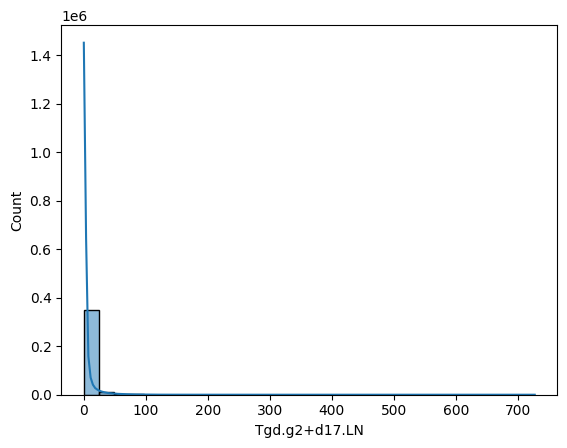

In [19]:
sns.histplot(ATAC_pfiltered["Tgd.g2+d17.LN"], bins=30, kde=True)

**Verteilung rechtsschief:**
<br> sehr viele Peaks/Regionen haben niedrige ATAC-Signale
<br>wenige Peaks/Regionen haben hohe ATAC-Signale
<br>der lange rechte Schwanz zeigt: einige, aber weige Regionen sind besonders stark zugänglich/open chromatin

## Filtering by Variation

In [20]:
exclude_cols = [
    "ImmGenATAC1219.peakID",
    "chrom",
    "Summit",
    "mm10.60way.phastCons_scores",
    "_-log10_bestPvalue",
    "Included.in.systematic.analysis",
    "TSS",
    "genes.within.100Kb"
]

ATAC_celltypes = ATAC_pfiltered.drop(columns=exclude_cols).copy()
ATAC_celltypes.head()

,LTHSC.34-.BM,LTHSC.34+.BM,STHSC.150-.BM,MPP4.135+.BM,proB.CLP.BM,proB.FrA.BM,proB.FrBC.BM,preB.FrD.BM,B.FrE.BM,B1b.PC,...,DC.4+.Sp,DC.8+.Sp,DC.pDC.Sp,DC.103+11b+.SI,DC.103+11b-.SI,FRC.SLN,IAP.SLN,BEC.SLN,LEC.SLN,Ep.MEChi.Th
2,2.36,0.10,0.90,0.11,0.47,0.10,0.50,1.17,0.32,0.14,...,0.87,0.54,2.72,0.95,0.11,63.38,8.92,1.33,1.04,0.11
3,0.41,0.10,0.11,0.11,0.79,0.40,0.50,2.23,0.80,0.14,...,0.44,1.83,0.66,0.11,0.92,13.50,0.98,1.28,1.04,0.11
4,0.41,0.10,0.11,0.11,0.47,0.34,1.78,1.17,0.32,0.60,...,0.44,0.10,0.66,1.79,0.51,0.92,0.75,1.33,1.61,4.50
5,2.36,1.64,1.85,1.58,1.12,0.34,0.42,0.13,0.80,0.60,...,1.34,0.29,0.23,0.89,0.11,0.53,1.40,0.90,2.87,9.09
6,0.41,0.10,0.11,0.11,0.11,1.34,0.90,1.69,0.80,0.60,...,0.87,1.93,0.59,0.11,1.39,2.58,0.75,2.30,2.34,11.02


<Axes: ylabel='Count'>

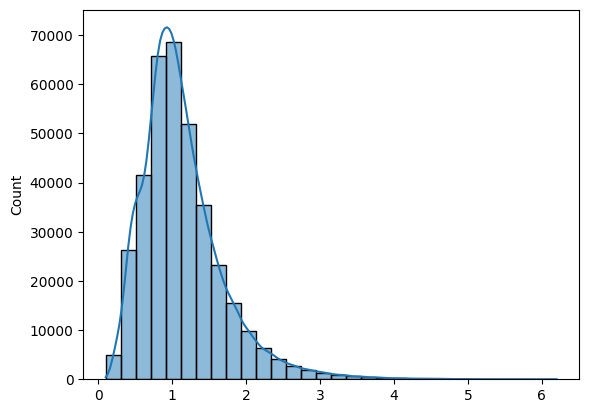

In [21]:
OCR_var_coef = ATAC_celltypes.std(axis=1) / ATAC_celltypes.mean(axis=1)
sns.histplot(OCR_var_coef, bins=30, kde=True)

In [22]:
OCR_var_coef.describe()

count    362330.000000
mean          1.138197
std           0.554413
min           0.103492
25%           0.775821
50%           1.038506
75%           1.387520
max           6.200528
dtype: float64

/var/folders/cc/3r9cpp9s7c9_s16wz91nlkn40000gn/T/ipykernel_11097/485437808.py:2: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(np.log2(ATAC_celltypes.mean(axis=1)), OCR_var_coef, s=5, cmap='viridis', alpha=0.5)


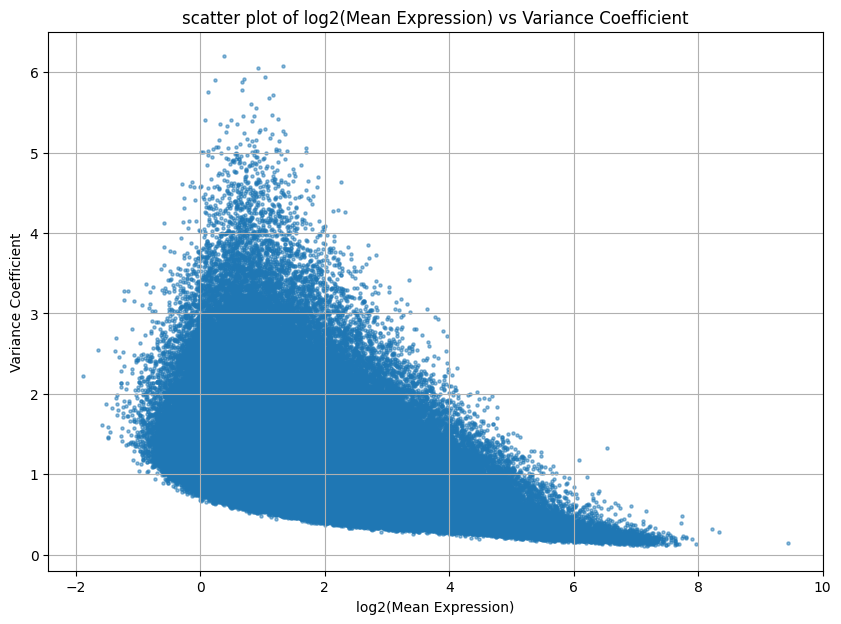

In [23]:
plt.figure(figsize=(10,7))
plt.scatter(np.log2(ATAC_celltypes.mean(axis=1)), OCR_var_coef, s=5, cmap='viridis', alpha=0.5)
plt.xlabel('log2(Mean Expression)')
plt.ylabel('Variance Coefficient')
plt.title('scatter plot of log2(Mean Expression) vs Variance Coefficient')
plt.grid(True)
plt.show()

## QC Datensatz analysieren

In [24]:
mmc1_path = Path('data') / 'mmc1.xlsx'
mmc1_data = pd.read_excel(mmc1_path)
mmc1_data.head() #head: zeigt nur erste 5 Zeilen --> trotzdem alles geladen


,SampleName,CellType,ImmGenLab,Lineage,CellFamily,Organ,SortingMarkers,InputCellNumber,PF.reads,%chrM.mapped,Paired.read.after.removing.PCR.duplication,%fragment.1Kb_TSS,Replicate.cor
0,LTHSC.34-.BM#1,LTHSC.34-.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150+CD48-CD34-,677,22287984,4.58,2470102,10.60,NaN
1,LTHSC.34+.BM#1,LTHSC.34+.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150+CD48-CD34+,2483,28588536,3.17,7675501,7.70,NaN
2,STHSC.150-.BM#1,STHSC.150-.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150-CD48-,3660,22170346,3.25,6060045,11.13,NaN
3,MPP4.135+.BM#1,MPP4.135+.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135+,10000,24003590,13.83,6128252,18.96,NaN
4,proB.CLP.BM#1,proB.CLP.BM,Hardy,B,B Cell,Bone Marrow,CD19-IgM-CD43+CD24-CD45R-CD93+CD117+IL7Ra+PI-D...,10000,23578208,7.67,6588564,13.21,0.868


In [25]:
mmc1_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 181 entries, 0 to 180
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   SampleName                                  181 non-null    str    
 1   CellType                                    181 non-null    str    
 2   ImmGenLab                                   181 non-null    str    
 3   Lineage                                     181 non-null    str    
 4   CellFamily                                  181 non-null    str    
 5   Organ                                       181 non-null    str    
 6   SortingMarkers                              181 non-null    str    
 7   InputCellNumber                             181 non-null    int64  
 8   PF.reads                                    181 non-null    int64  
 9   %chrM.mapped                                181 non-null    float64
 10  Paired.read.after.removin

181 cell samples --> und ATAC sind um die 90. Um QC zu analysieren die rausgenommen QC metrics enternen

alle rows bei QC droppen, deren namen nicht in ATAC_data_removed beinhaltet sind

In [26]:
mmc1_removed = mmc1_data[mmc1_data["CellType"].isin(ATAC_pfiltered.columns)].copy()
mmc1_removed.info()

<class 'pandas.DataFrame'>
Index: 179 entries, 0 to 180
Data columns (total 13 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   SampleName                                  179 non-null    str    
 1   CellType                                    179 non-null    str    
 2   ImmGenLab                                   179 non-null    str    
 3   Lineage                                     179 non-null    str    
 4   CellFamily                                  179 non-null    str    
 5   Organ                                       179 non-null    str    
 6   SortingMarkers                              179 non-null    str    
 7   InputCellNumber                             179 non-null    int64  
 8   PF.reads                                    179 non-null    int64  
 9   %chrM.mapped                                179 non-null    float64
 10  Paired.read.after.removing.PCR

--> es wurden 2 entfernt: stromale fibroblastic reticular cells (keine klassischen Immunzellen)

In [27]:
mmc1_notremoved = mmc1_data[~mmc1_data["CellType"].isin(ATAC_pfiltered.columns)].copy()
mmc1_notremoved.head()

,SampleName,CellType,ImmGenLab,Lineage,CellFamily,Organ,SortingMarkers,InputCellNumber,PF.reads,%chrM.mapped,Paired.read.after.removing.PCR.duplication,%fragment.1Kb_TSS,Replicate.cor
171,FRC.CD140a+.Madcam-.CD35-.SLN#1,FRC.CD140a+.Madcam-.CD35-.SLN,Turley,stroma,Fibroblastic reticular cell,skin draining Lymph Node,CalceinBlue+PDPN+CD31-CD21/35-Madcam1-LiveDead...,10000,25768696,6.16,8039453,7.65,0.897
172,FRC.CD140a+.Madcam-.CD35-.SLN#2,FRC.CD140a+.Madcam-.CD35-.SLN,Turley,stroma,Fibroblastic reticular cell,skin draining Lymph Node,CalceinBlue+PDPN+CD31-CD21/35-Madcam1-LiveDead...,10000,66673554,6.87,15351027,7.40,0.897


**haben manche Samples sehr weinge reads?**

In [28]:
mmc1_data["PF.reads"].describe()

count    1.810000e+02
mean     2.459027e+07
std      6.575663e+06
min      1.614223e+07
25%      2.104140e+07
50%      2.319932e+07
75%      2.587249e+07
max      6.667355e+07
Name: PF.reads, dtype: float64

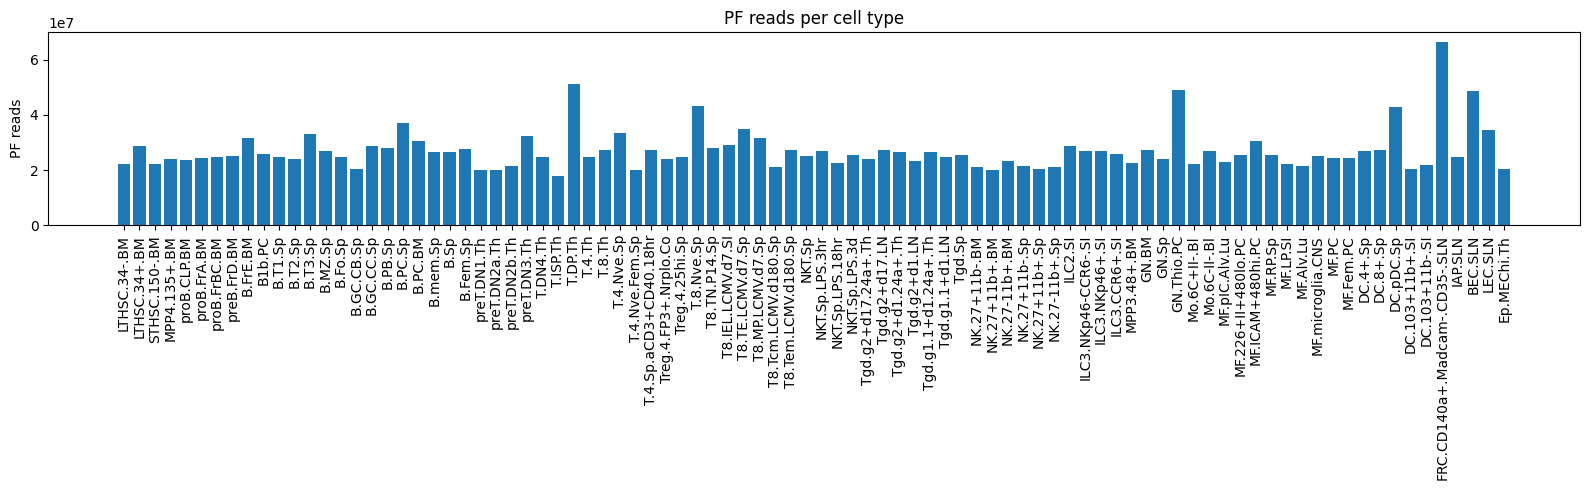

In [29]:
plt.figure(figsize=(16,5))
plt.bar(mmc1_data["CellType"], mmc1_data["PF.reads"])
plt.xticks(rotation=90)
plt.ylabel("PF reads")
plt.title("PF reads per cell type")
plt.tight_layout()
plt.show()

nach dem paper wurde ein threshold von 2,470,102. Minimum bei 16 Millionen: deutlich drüber

**Missing values**

In [30]:
#number of missing data points per column
missing_values_count_mmc1 = mmc1_data.isnull().sum()
missing_values_count_mmc1[missing_values_count_mmc1 > 0] #just show columes where data is missing

Replicate.cor    5
dtype: int64

In [31]:
mmc1_data[mmc1_data["Replicate.cor"].isnull()]

,SampleName,CellType,ImmGenLab,Lineage,CellFamily,Organ,SortingMarkers,InputCellNumber,PF.reads,%chrM.mapped,Paired.read.after.removing.PCR.duplication,%fragment.1Kb_TSS,Replicate.cor
0,LTHSC.34-.BM#1,LTHSC.34-.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150+CD48-CD34-,677,22287984,4.58,2470102,10.60,NaN
1,LTHSC.34+.BM#1,LTHSC.34+.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150+CD48-CD34+,2483,28588536,3.17,7675501,7.70,NaN
2,STHSC.150-.BM#1,STHSC.150-.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150-CD48-,3660,22170346,3.25,6060045,11.13,NaN
3,MPP4.135+.BM#1,MPP4.135+.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135+,10000,24003590,13.83,6128252,18.96,NaN
127,MPP3.48+.BM#1,MPP3.48+.BM,Wagers,Stem&Prog,Stem&Prog Cell,Bone Marrow,Lin-Sca1+ckit+CD135-CD150-CD48+,10000,22469306,3.91,7429716,9.25,NaN


**Missing values in mmc1**

<br> Replicate correlation einzige colume mit missing Werte: 5 missing Werte. <br>

Im paper wurde: <br>
<i><small> "(3) Concordance between the two biological replicates. We
selected, for each cell-type, a subset of OCRs in which the raw edge counts were >= 10 in at
least one replicate, which was used to compute a Pearson correlation between the two
replicates. The Pearson coefficient is sensitive to the total number of reads (as evidenced by
the B cell pilot, Fig. S1B left). The samples retained for the analysis exhibited comparable
inter replicates correlations to the trend estimated from B cell pilots (green line, Fig. S1B
right)." </i></small>

Das bedeutet:<br>
es misst die Reproduzierbarkeit des ATAC-seq accesssibility profiles zwischen biologischen Repliakte des selben Zelltypes (Sample #1 oder #2)<br>
**Hohe Werte:** beide replicate ähnlcihe accesibility Muster über OCR --> gute Datenqualität<br>
**Keine Wertte:** einach nur ein Sample vorhanden oder keine Repliakte - Correlation...

**mmc1 Analyse metrics columes** 

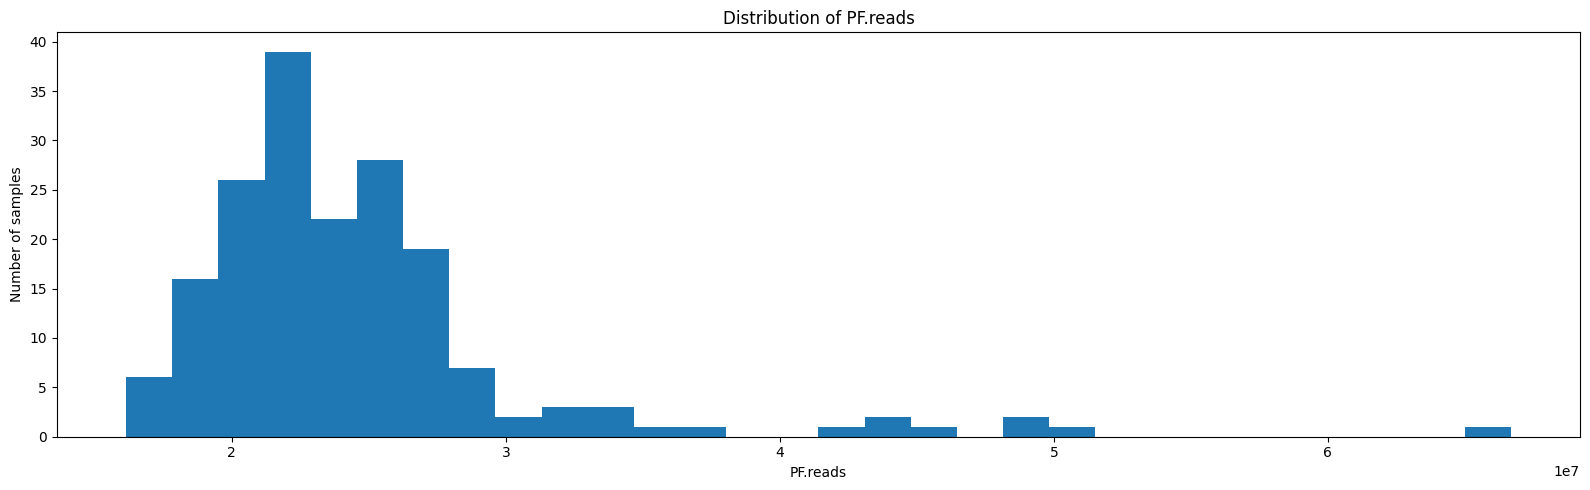

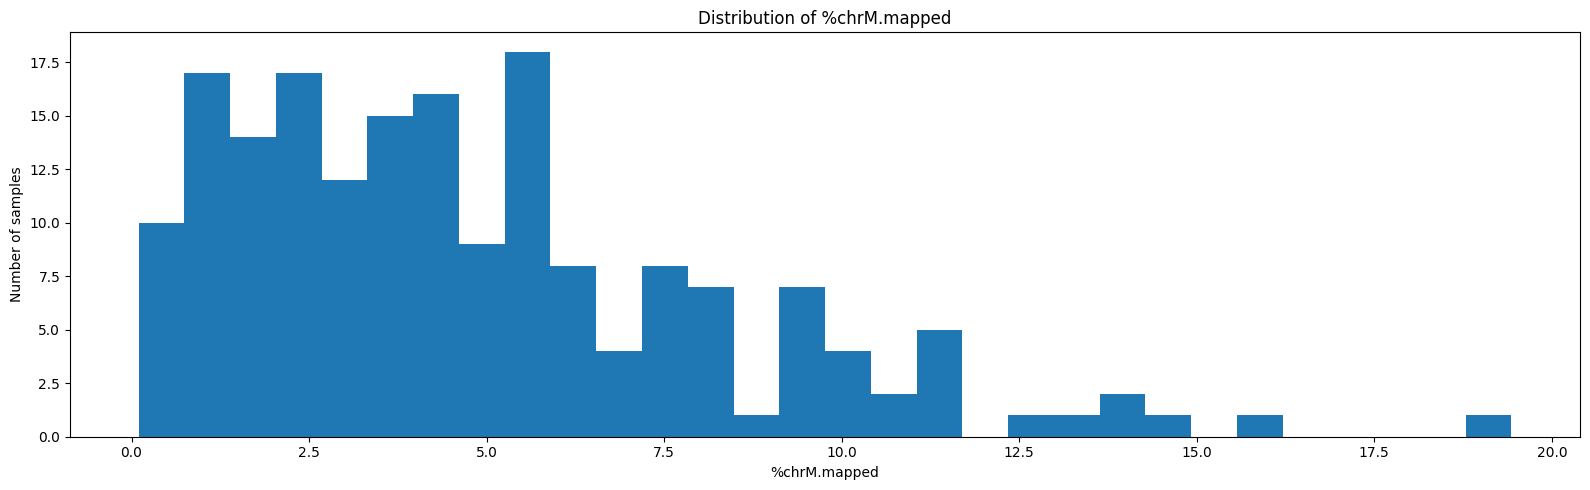

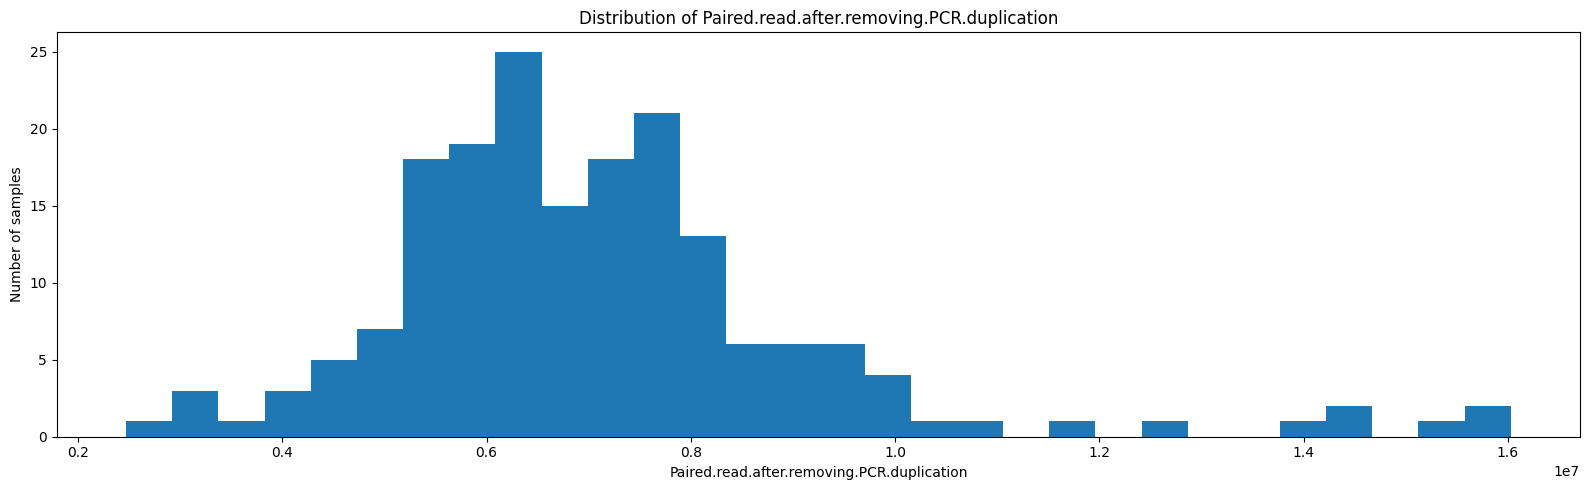

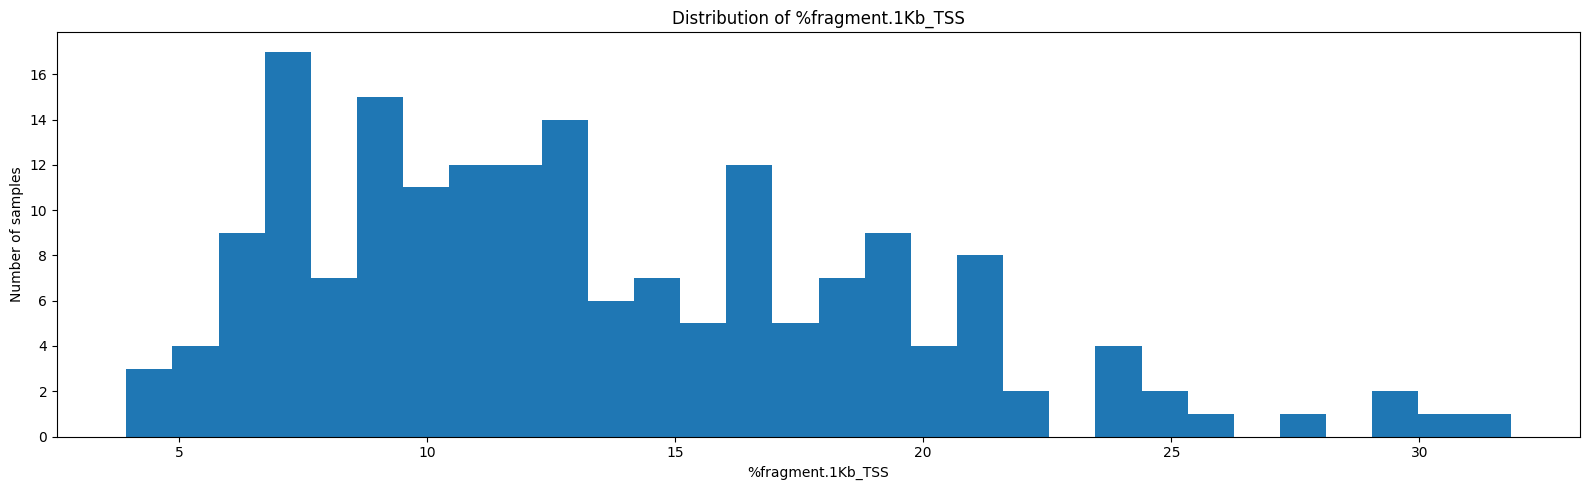

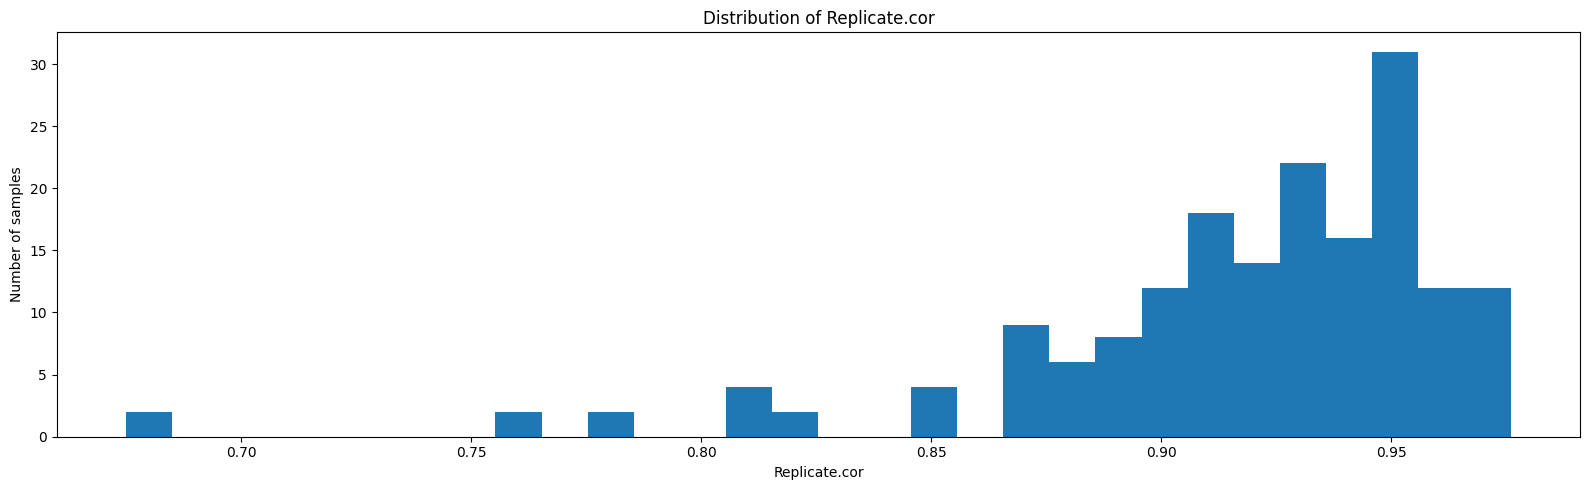

In [32]:
mmc1_parameter = [
    "PF.reads",
    "%chrM.mapped",
    "Paired.read.after.removing.PCR.duplication",
    "%fragment.1Kb_TSS",
    "Replicate.cor"
]

for parameter in mmc1_parameter:
    plt.figure(figsize=(16,5))
    plt.hist(mmc1_data[parameter].dropna(), bins=30)
    plt.xlabel(parameter)
    plt.ylabel("Number of samples")
    plt.title(f"Distribution of {parameter}" ) # f-String: variable in geschweiften Klammern, setzt Werte automatisch ein
    plt.tight_layout()
    plt.show()



## 1.2 Signal Variability Across CREs
<h2> Should any peaks be filtered out due to insufficient signal?

Wie viel ATAC-Signal hat dieser Peak insgesamt über alle verwendeten Zelltypen/Samples?

In [33]:
annotation_cols = [
    "ImmGenATAC1219.peakID",
    "Summit",
    "chrom",
    "mm10.60way.phastCons_scores",
    "_-log10_bestPvalue",
    "Included.in.systematic.analysis",
    "TSS",
    "genes.within.100Kb"
]

ATAC_signal = ATAC_pfiltered.drop(columns=annotation_cols)
peak_total = ATAC_signal.sum(axis=1)
peak_total.describe()

count    362330.000000
mean        458.318951
std         887.305913
min          24.420000
25%         137.700000
50%         207.290000
75%         407.510000
max       62693.390000
dtype: float64

Annotations-Spalten entfernen<br>
Gesamtsignal pro Peak berechnen (Peak 1: Signal in Sample1 + Sample2 ...; Peak 2: Signal in Sample1 + Sample2 ... )<br>

<h3>Low-Signal Peaks prüfen</h3>

In [34]:
low_signal_peaks = peak_total == 0

print("Total CREs:", ATAC_signal.shape[0])
print("Zero-signal CREs:", low_signal_peaks.sum())
print("Percent zero-signal CREs:", low_signal_peaks.mean() * 100)

Total CREs: 362330
Zero-signal CREs: 0
Percent zero-signal CREs: 0.0


In [35]:
nonzero_peak = (ATAC_signal > 0).sum(axis=1) # > Vergleichsoperator --> gibt boolean zurück
nonzero_peak.describe()

count    362330.0
mean         90.0
std           0.0
min          90.0
25%          90.0
50%          90.0
75%          90.0
max          90.0
dtype: float64

kein peak hat Gesamtsignal 0, jeder Peak hat in allen 90 Samples ein Signal > 0

In [36]:
peak_total_signal = ATAC_signal.sum(axis=1)
peak_total_signal.describe()

count    362330.000000
mean        458.318951
std         887.305913
min          24.420000
25%         137.700000
50%         207.290000
75%         407.510000
max       62693.390000
dtype: float64

(array([1.0000e+00, 0.0000e+00, 2.0000e+00, 6.0000e+00, 8.0000e+00,
        2.0000e+01, 2.3000e+01, 5.7000e+01, 1.2800e+02, 2.1900e+02,
        4.3500e+02, 8.4000e+02, 1.4250e+03, 2.3650e+03, 3.6430e+03,
        5.6470e+03, 7.6470e+03, 1.0412e+04, 1.2624e+04, 1.4898e+04,
        1.7025e+04, 1.8141e+04, 1.8766e+04, 1.8252e+04, 1.7544e+04,
        1.6586e+04, 1.5476e+04, 1.4234e+04, 1.2741e+04, 1.1939e+04,
        1.0856e+04, 1.0098e+04, 9.2670e+03, 8.4030e+03, 7.9060e+03,
        7.4310e+03, 7.0310e+03, 6.3330e+03, 6.1450e+03, 5.6660e+03,
        5.2140e+03, 4.9440e+03, 4.5460e+03, 4.2320e+03, 3.9770e+03,
        3.6300e+03, 3.3000e+03, 3.0600e+03, 2.8740e+03, 2.5800e+03,
        2.3300e+03, 2.0980e+03, 1.8910e+03, 1.6970e+03, 1.5480e+03,
        1.3260e+03, 1.3010e+03, 1.1760e+03, 1.1100e+03, 1.0230e+03,
        9.4300e+02, 8.2500e+02, 7.3200e+02, 6.5600e+02, 6.1700e+02,
        5.8400e+02, 5.7000e+02, 5.2100e+02, 4.2900e+02, 3.8600e+02,
        3.3800e+02, 3.0800e+02, 2.7000e+02, 2.36

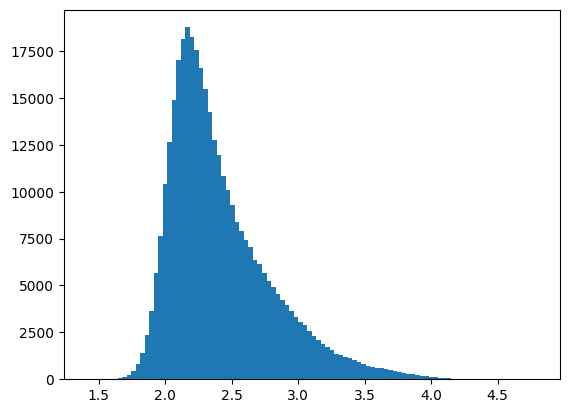

In [37]:
plt.hist(np.log10(peak_total_signal + 1), bins=100)

<h3>Mittelwertfilter </h3> <p style="color: red;"> Rausnehmen </p> weil haben schon geiltert macht kein Sinn noch anhand Mittelwert Werte zu entfernen
<br>Filter über niedrigen Mittelwert --> aber kann biologisch interessante sein, da sehr zelltypspezifische Peaks entfernt werden

In [38]:
peak_mean = ATAC_signal.mean(axis=1)
peak_std = ATAC_signal.std(axis=1)

threshold_mean = peak_mean.quantile(0.05) #untersten 5% der peaks

ATAC_data_peaks =ATAC_pfiltered


 <p style="color: pink;"> Should any peaks be filtered out due to insufficient signal?</p>

The data come from a prefiltered and systematically analyzed OCR set. As described in the paper by Yoshida et al., the OCRs were sorted out, quantified, and normalized, thereby filtering out blacklisted genomic regions and chromosome homologous regions, thus removing possible artifacts. <br>
Also, when looking at the QC data (mmc1 data), the samples show sufficient quality, so no additional broad filtering of peaks due to insufficient signal was necessary. <br>
Additionaly all data with a p value under 0.05 (5%) were removed, setting a threshold for unreliable data and removing possible OCRs caused by background noise. <br>
Checking the minimum ATAC signal across the OCR, there were no peaks that had a signal of zero. There was no evidence for complet abscent signals and low signal peaks will be needed for analyzing the accesibility

## 1.4 CRE Classification

<h3> Can CREs be grouped into distinct classes based on signal level and cross-cell variability? Within all cell types or lineage specific? </h3>

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

ATAC_seq = pd.read_csv('data/ATAC_pfiltered.csv')

ATAC_seq_gd_path = Path('data') / 'ATAC_seq_gd.csv'
ATAC_seq_gd = pd.read_csv(ATAC_seq_gd_path)
ATAC_seq_gd.head()

,ImmGenATAC1219.peakID,chrom,Summit,mm10.60way.phastCons_scores,_-log10_bestPvalue,Included.in.systematic.analysis,TSS,genes.within.100Kb,MPP4.135+.BM,preT.DN1.Th,...,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN
0,ImmGenATAC1219.peak_3,chr1,3120109,0.07,10.80,1.0,NaN,NaN,0.11,0.40,...,0.11,0.10,0.35,0.11,0.76,0.53,1.46,0.11,0.12,0.86
1,ImmGenATAC1219.peak_4,chr1,3121485,0.15,3.02,1.0,NaN,NaN,0.11,0.46,...,0.47,0.10,0.58,0.11,0.29,0.53,0.51,0.11,0.70,0.13
2,ImmGenATAC1219.peak_5,chr1,3372787,0.03,1.31,NaN,NaN,NaN,0.11,0.77,...,1.34,1.69,0.34,1.39,1.58,3.16,0.51,0.99,0.12,0.73
3,ImmGenATAC1219.peak_6,chr1,3399217,0.06,2.39,1.0,NaN,NaN,1.58,0.77,...,0.47,1.02,0.10,1.33,0.10,1.48,0.15,0.11,1.26,0.73
4,ImmGenATAC1219.peak_7,chr1,3400115,0.44,2.57,1.0,NaN,NaN,0.11,0.40,...,0.47,0.10,0.58,1.33,1.27,1.11,0.51,2.86,0.70,0.73


In [40]:
annotation_cols = [
    "Summit",
    "chrom",
    "mm10.60way.phastCons_scores",
    "_-log10_bestPvalue",
    "Included.in.systematic.analysis",
    "TSS",
    "genes.within.100Kb"
]

ATAC_signal_Tgd = ATAC_seq_gd.drop(columns=annotation_cols)
ATAC_signal_Tgd.shape

(362330, 14)

In [41]:
annotation_col = [
    "ImmGenATAC1219.peakID"	
] 
    
    

ATAC_signal_Tgd_numeric = ATAC_signal_Tgd.drop(columns=annotation_col)
ATAC_signal_Tgd_numeric.shape

(362330, 13)

**Clustering of Peaks (CREs) based on Tgd celltypes**

In [42]:
peak_mean_Tgd = ATAC_signal_Tgd_numeric.mean(axis=1) # Mittelwert über alle Tgd-Zelltypen für jeden peak

peak_std_Tgd = ATAC_signal_Tgd_numeric.std(axis=1) # Standardabweichung über alle Tgd-Zelltypen für jeden peak

peak_var_Tgd = ATAC_signal_Tgd_numeric.var(axis=1) # Varianz über alle Tgd-Zelltypen für jeden peak

#varianz und std sind redundant
cre_parameter = pd.DataFrame({"mean_signal": peak_mean_Tgd, "std": peak_std_Tgd}, index=ATAC_signal_Tgd_numeric.index)
cre_parameter.head()

,mean_signal,std
0,0.445385,0.418243
1,0.323846,0.222843
2,1.043846,0.822319
3,0.759231,0.546526
4,0.846923,0.718614


**Scatterplot der Peaks**

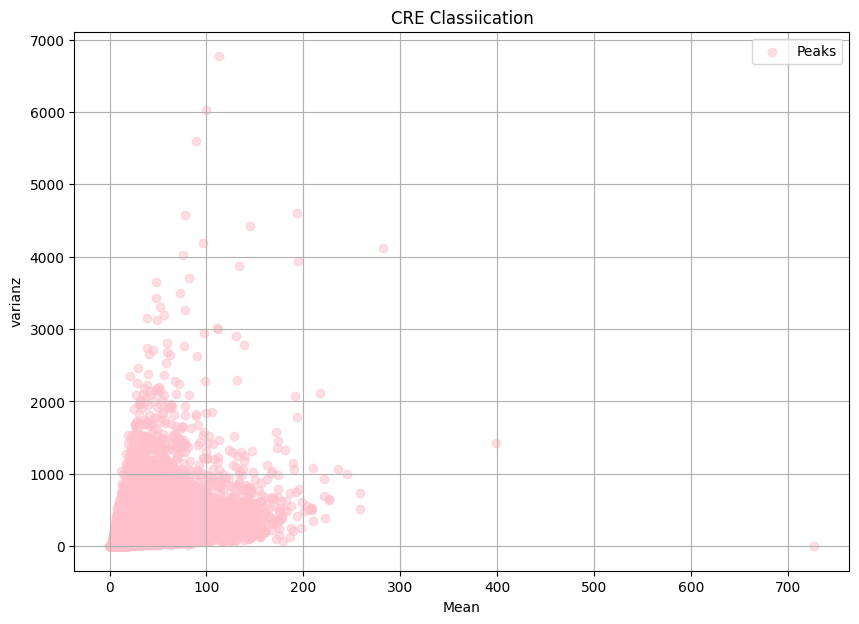

In [43]:
plt.figure(figsize=(10, 7))
plt.scatter(peak_mean_Tgd, peak_var_Tgd, label='Peaks', color='pink', alpha=0.5) # desto stärker pink --> Dichte höher
plt.xlabel('Mean')
plt.ylabel('varianz')
plt.title('CRE Classiication')
plt.legend()
plt.grid(True)
plt.show()

**PCA analysis**

—> z-transformation: (Erwartungswert = 0, aufgrund zentrieren, Standartabw. 1(wegen skalieren))<br>
centering: Mittelwert und dann jeden Punkt vom Mittelwert abziehen<br>
scaling: für jede Variable Standartabweichung 

**hier jz ohne z-transformation**

In [45]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca = PCA(n_components=2)
pcs = pca.fit_transform(ATAC_signal_Tgd_numeric.values) #Dimensionsreduktion

pca_ATAC_peaks = pd.DataFrame(
    data=pcs, 
    columns=['PC1', 'PC2'], 
    index=ATAC_signal_Tgd_numeric.index)

print(pca.explained_variance_ratio_)
pca_ATAC_signal_exp_var = pca.explained_variance_ratio_
print(pca.explained_variance_ratio_.cumsum()) #cumulative sum, Array von Zahlen von links nach rechts aufaddiert

[0.85381132 0.05299556]
[0.85381132 0.90680688]


Die ersten beiden PCA erklären schon über 90% der gesamt Varianz

In [46]:
pc1_data = pca_ATAC_peaks['PC1']
correlation_matrix = np.corrcoef(pc1_data, peak_mean)
correlation = correlation_matrix[0, 1]
print(correlation)

0.9503609519233596


Eine Korrelation von fast 1 bedeuetet, dass PC1 und der Mittelwert der Peaks fast komplett prop. zu einander sind. PC1 beschreibt die Signalstärke. "Sortiert" schwache Peaks bis extrem starke peaks.  

visualizing PCA results: Färben nach durchschnittlichen Signal

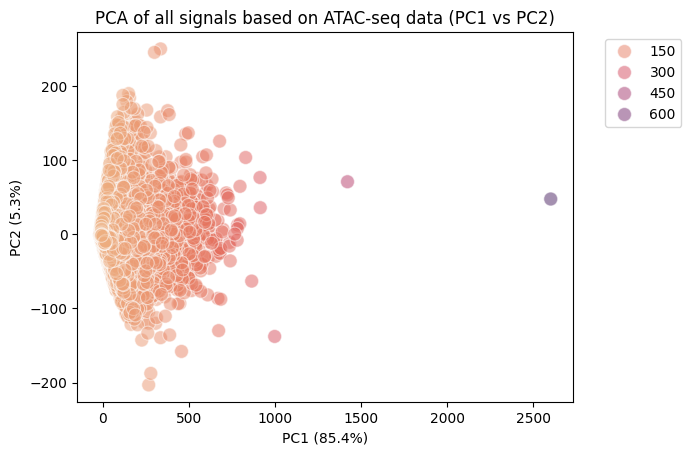

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

pca_ATAC_peaks['mean_Signal'] = peak_mean_Tgd

sns.scatterplot(
    data=pca_ATAC_peaks,
    x="PC1",
    y="PC2",
    hue="mean_Signal",
    palette=sns.color_palette("flare", as_cmap=True),
    s=100,
    alpha=0.5
)


plt.xlabel("PC1" + f" ({pca_ATAC_signal_exp_var[0]:.1%})")
plt.ylabel("PC2" + f" ({pca_ATAC_signal_exp_var[1]:.1%})")
plt.title("PCA of all signals based on ATAC-seq data (PC1 vs PC2)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

Zahlen 0 - 600 durchschnittliche Signalstärke. 
Keine Cluster zu erkennen --> man kann nicht anhand Signalstärke nicht in clusters einteilen?

visualizing PCA results: Färben nach Variabilität

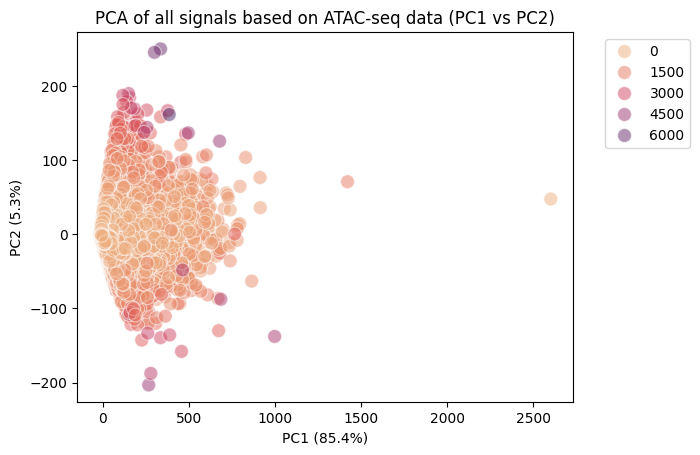

In [48]:
pca_ATAC_peaks['var_Signal'] = peak_var_Tgd

sns.scatterplot(
    data=pca_ATAC_peaks,
    x="PC1",
    y="PC2",
    hue="var_Signal",
    palette=sns.color_palette("flare", as_cmap=True),
    s=100,
    alpha=0.5
)


plt.xlabel("PC1" + f" ({pca_ATAC_signal_exp_var[0]:.1%})")
plt.ylabel("PC2" + f" ({pca_ATAC_signal_exp_var[1]:.1%})")
plt.title("PCA of all signals based on ATAC-seq data (PC1 vs PC2)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

vielleicht liebr k-means clustering, weil wenige Dimensionen vorhanden sind.

**K-means clustering** (Code siehe Tilmann)

kmeans clustering: **ohne** z-transformation: absolute signalstärke dominiert: Peaks mit hohen Wert in einem Cluster, mittleren ...

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import zscore

silhouette_scores = []
k_values = range(2, 20)


for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(ATAC_signal_Tgd_numeric)
    score = silhouette_score(ATAC_signal_Tgd_numeric, labels, sample_size=10000, random_state=42)    
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")

best_k = k_values[np.argmax(silhouette_scores)]
print(f"\nBeste Clusteranzahl laut Silhouette-Score: k={best_k}")

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), silhouette_scores, color="steelblue")
plt.xticks(list(k_values))
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score for KMeans on ATAC peaks data")
plt.grid(True, alpha=0.3)
plt.show()

k=2: silhouette score = 0.8568
k=3: silhouette score = 0.7702
k=4: silhouette score = 0.6831
k=5: silhouette score = 0.6104
k=6: silhouette score = 0.5492


Kmeans Clustering z-transformation auf alle ATAC Daten


k=2: silhouette score = 0.1504
k=3: silhouette score = 0.1431
k=4: silhouette score = 0.1485
k=5: silhouette score = 0.1478
k=6: silhouette score = 0.1250
k=7: silhouette score = 0.1236
k=8: silhouette score = 0.1245
k=9: silhouette score = 0.1227
k=10: silhouette score = 0.1229
k=11: silhouette score = 0.1235
k=12: silhouette score = 0.1209
k=13: silhouette score = 0.1175
k=14: silhouette score = 0.1075
k=15: silhouette score = 0.0993
k=16: silhouette score = 0.0953
k=17: silhouette score = 0.0945
k=18: silhouette score = 0.0924
k=19: silhouette score = 0.0914

Beste Clusteranzahl laut Silhouette-Score: k=2


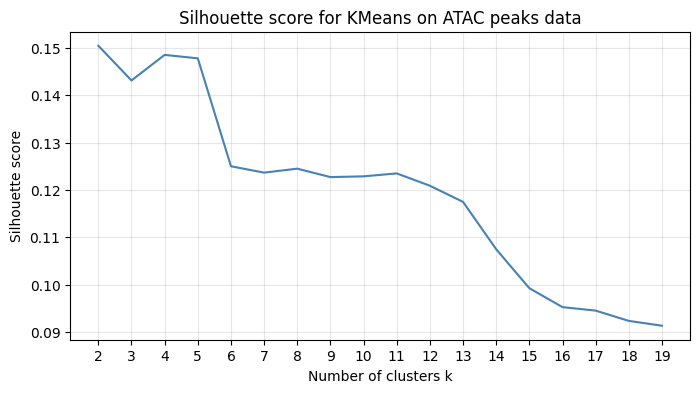

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import zscore

#Zeilenweise z-trasnformation, hin und zurück transponieren
X_z = StandardScaler().fit_transform(ATAC_signal_Tgd_numeric.T).T

silhouette_scores = []
k_values = range(2, 20)


for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X_z)
    score = silhouette_score(X_z, labels, sample_size=10000, random_state=42)    
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")

best_k = k_values[np.argmax(silhouette_scores)]
print(f"\nBeste Clusteranzahl laut Silhouette-Score: k={best_k}")

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), silhouette_scores, color="steelblue")
plt.xticks(list(k_values))
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score for KMeans on ATAC peaks data")
plt.grid(True, alpha=0.3)
plt.show()

Kmeans Clustering z-transformation, aber nur auf tabbelle: mean und std

k=2: silhouette score = 0.8181
k=3: silhouette score = 0.7499
k=4: silhouette score = 0.6924
k=5: silhouette score = 0.6442
k=6: silhouette score = 0.6447
k=7: silhouette score = 0.5911
k=8: silhouette score = 0.6011
k=9: silhouette score = 0.5549
k=10: silhouette score = 0.5590
k=11: silhouette score = 0.5252
k=12: silhouette score = 0.5352
k=13: silhouette score = 0.5241
k=14: silhouette score = 0.5246
k=15: silhouette score = 0.5112
k=16: silhouette score = 0.5120
k=17: silhouette score = 0.5036
k=18: silhouette score = 0.4872
k=19: silhouette score = 0.4873

Beste Clusteranzahl laut Silhouette-Score: k=2


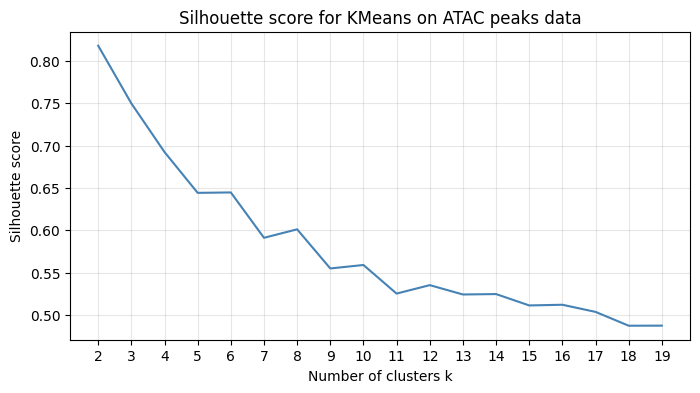

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import zscore

#Spaltenwiese z-trasnformation

X = StandardScaler().fit_transform(cre_parameter)

silhouette_scores = []
k_values = range(2, 20)


for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels, sample_size=10000, random_state=42)    
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")

best_k = k_values[np.argmax(silhouette_scores)]
print(f"\nBeste Clusteranzahl laut Silhouette-Score: k={best_k}")

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), silhouette_scores, color="steelblue")
plt.xticks(list(k_values))
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score for KMeans on ATAC peaks data")
plt.grid(True, alpha=0.3)
plt.show()

beste Cluster bei k = 2. (sehr grobe Aufteilung) <br>
--> lokale Maxima bei k = 3 und k = 5 (verwenden für Hierarchisches Clustering)

cluster für k=5

In [ ]:
from sklearn.cluster import KMeans

k_means = KMeans(n_clusters=5, random_state=42)
labels = k_means.fit_predict(X)

cre_parameter_clustered = cre_parameter.copy()
cre_parameter_clustered["cluster"] = labels

cluster_profiles = cre_parameter_clustered.groupby("cluster").mean()
print(cluster_profiles)

         mean_signal        std
cluster                        
0           7.422506   4.425284
1          18.644208   9.925953
2         101.988649  19.082620
3          41.987680  17.415802
4           1.799826   1.208358


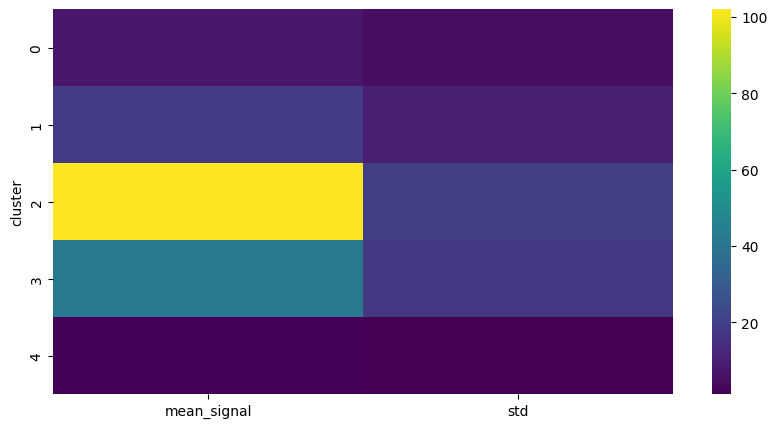

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
sns.heatmap(cluster_profiles, cmap="viridis")
plt.show()

clusters machen biologisch kein Sinn

**variablsten Peaks auswählen**
20.000 variabelsten peaks: CREs, die überhaupt noch aktiv sind

In [ ]:
peak_var_Tgd = ATAC_signal_Tgd.var(axis=1)

top_peaks = ATAC_signal_Tgd.loc[peak_var_Tgd.nlargest(20000).index]

z-transformation

In [ ]:
X_z = (top_peaks.sub(top_peaks.mean(axis=1), axis=0).div(top_peaks.std(axis=1),axis=0))

noch Mal PCA durchführen aber nur auf variabelsten peaks

In [ ]:
pca = PCA(n_components=2)
pcs = pca.fit_transform(X_z) #Dimensionsreduktion

pca_top_peaks= pd.DataFrame(
    data=pcs, 
    columns=['PC1', 'PC2'], 
    index=top_peaks.index)

print(pca.explained_variance_ratio_)
pca_top_peaks_exp_var = pca.explained_variance_ratio_
print(pca.explained_variance_ratio_.cumsum()) #cumulative sum, Array von Zahlen von links nach rechts aufaddiert

[0.35719886 0.21952582]
[0.35719886 0.57672468]


visualizing PCA of most variable peaks

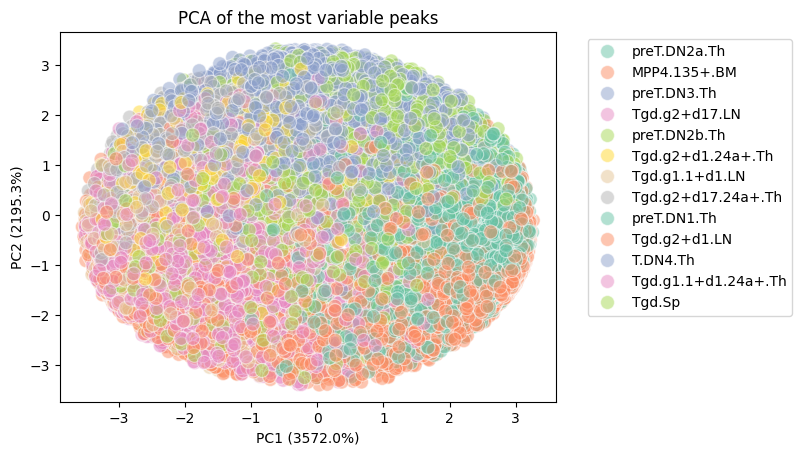

In [ ]:
import seaborn as sns 
import matplotlib.pyplot as plt

celltypes = X_z.idxmax(axis=1) #jeder Peak eingefärbt nach dem Zelltyp, in dem er sein maximum hat
pca_top_peaks["cell_type"] = celltypes.loc[pca_top_peaks.index]

sns.scatterplot(
    data=pca_top_peaks,
    x="PC1",
    y="PC2",
    hue="cell_type",
    palette="Set2",
    s=100, 
    alpha=0.5
)

plt.xlabel("PC1" + f" ({pca_top_peaks_exp_var [0]*100:.1%})")
plt.ylabel("PC2" + f" ({pca_top_peaks_exp_var[1]*100:.1%})")
plt.title("PCA of the most variable peaks")
plt.legend (bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

top variablsten peaks nach Umap clustern (tilmann) --> code funktioniert noch nicht, muss ich ferigstellen

In [ ]:
cells_groups_path = Path('data') / 'cells_groups.csv'
cells_groups = pd.read_csv(cells_groups_path)
cells_groups.head()

,gdT,abT,Act_T,B_cells,Stem,ILC,MF/GN,Mo,DC,Stroma
0,Tgd.g2+d17.24a+.Th,preT.DN1.Th,T.4.Sp.aCD3+CD40.18hr,proB.CLP.BM,LTHSC.34-.BM,NK.27+11b-.BM,GN.BM,Mo.6C+II-.Bl,DC.4+.Sp,FRC.SLN
1,Tgd.g2+d17.LN,preT.DN2a.Th,T8.TN.P14.Sp,proB.FrA.BM,LTHSC.34+.BM,NK.27+11b+.BM,GN.Sp,Mo.6C-II-.Bl,DC.8+.Sp,IAP.SLN
2,Tgd.g2+d1.24a+.Th,preT.DN2b.Th,T8.IEL.LCMV.d7.SI,proB.FrBC.BM,STHSC.150-.BM,NK.27-11b+.BM,GN.Thio.PC,NaN,DC.pDC.Sp,BEC.SLN
3,Tgd.g2+d1.LN,preT.DN3.Th,T8.TE.LCMV.d7.Sp,preB.FrD.BM,MPP4.135+.BM,NK.27+11b-.Sp,MF.pIC.Alv.Lu,NaN,DC.103+11b+.SI,LEC.SLN
4,Tgd.g1.1+d1.24a+.Th,T.DN4.Th,T8.MP.LCMV.d7.Sp,B.FrE.BM,MPP3.48+.BM,NK.27+11b+.Sp,MF.226+II+480lo.PC,NaN,DC.103+11b-.SI,Ep.MEChi.Th


In [ ]:
cell_group_map = {
    cell: group
    for group in cells_groups.columns
    for cell in cells_groups[group].dropna()
}

top_peaks["cell_type"] = top_peaks.index.map(cell_group_map).fillna("other")

print("Gefundene Zelltypen im Original:", top_peaks["cell_type"].unique())

Tgd_cells = ["gdT", "abT"]
top_peaks_filtered = top_peaks[top_peaks["cell_type"].isin(Tgd_cells)]

top_peaks_filtered.shape
top_peaks_filtered.head()

Gefundene Zelltypen im Original: ['other']


,MPP4.135+.BM,preT.DN1.Th,preT.DN2a.Th,preT.DN2b.Th,preT.DN3.Th,T.DN4.Th,Tgd.g1.1+d1.24a+.Th,Tgd.g2+d1.24a+.Th,Tgd.g2+d17.24a+.Th,Tgd.Sp,Tgd.g1.1+d1.LN,Tgd.g2+d1.LN,Tgd.g2+d17.LN,cell_type


In [ ]:
print(top_peaks["cell_type"].unique())

['other']


In [ ]:
import umap

umap_reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric='euclidean', random_state=42)

X_raw = top_peaks_filtered.select_dtypes(float).values
X_raw_scaled = StandardScaler().fit_transform(X_raw)

X_umap = umap_reducer.fit_transform(X_raw_scaled)
umap_df = pd.DataFrame(
    X_umap,
    index=top_peaks_filtered.index,
    columns=['UMAP1', 'UMAP2']
)
umap_df['cell_type'] = top_peaks_filtered['cell_type']

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=umap_df,
    x='UMAP1',
    y='UMAP2',
    hue='cell_type',
    palette="Set2",
    s=100,
    alpha=0.8
)
plt.title('UMAP of all cell types based on raw ATAC-seq data of most variable peaks')
plt.xlabel('UMAP1')
plt.ylabel('UMAP2')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Hierarchical clustering**

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(ATAC_signal_Tgd_numeric.values) #Z -transformation, Daten standardisieren

cluster_number = 4 # 4 weil nach k-means clustering als lokales maximum
clustering = AgglomerativeClustering(linkage="ward", n_clusters=cluster_number).fit(X)

labels = clustering.labels_

Hierarchical_clustering = ATAC_signal_Tgd.copy()
Hierarchical_clustering ['Cluster'] = labels

print("\nAnzahl der Peaks pro Cluster:")
print(Hierarchical_clustering['Cluster'].value_counts())

In [ ]:
from sklearn.preprocessing import StandardScaler

X =  StandardScaler().fit_transform(ATAC_signal_Tgd_numeric.values)
print(X.shape)

(362330, 13)


In [ ]:
print(ATAC_signal_Tgd_numeric.shape)
print(ATAC_signal_Tgd_numeric.memory_usage(deep=True).sum()/1024**2, "MB")

(362330, 13)
35.93678665161133 MB


## Code nicht gebraucht wird

Den code darunter erst Mal ignorieren: Code vorlage für einer Seite für PCA, vllt sidebar in oberen code implementieren

In [ ]:
y_test = peak_mean_Tgd.values
plt.rcParams.update({'font.size': 18, 'font.family': 'sans serif'})

fig = plt.figure(figsize = (14,8)); 
ax = fig.add_subplot(1,1,1)
cmap = plt.cm.get_cmap('pink')

normalize = plt.Normalize(vmin=min(y_test), vmax=max(y_test))
scatterp = ax.scatter(pcs[:,0],pcs[:,1], s = 20, c= y_test, cmap = cmap, alpha=0.6)
ax.set(xlabel = '1st Principal Component (on test set)', ylabel= '2nd Principal Component (on test set)', \
       title =  'PCA with 2 components \n Test target values indicated with color and size')
cbar = fig.colorbar(scatterp, ax=ax)

**MiniBatchkmeans**

MiniBatchKMeans: K-Means clustering algorithm designed for bid datasets. processing of small, random subsets (mini-batches) of the data at a time, it drastically reduces computation time and memory usage while yielding clusters of nearly comparable quality. (Scikit-learn)

In [ ]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
from scipy.stats import zscore

#Spaltenwiese z-trasnformation

X = StandardScaler().fit_transform(cre_parameter)

silhouette_scores = []
k_values = range(2, 20)


for k in k_values:
    mbkm = MiniBatchKMeans(n_clusters=k, batch_size=4096, random_state=42, n_init=20)
    labels = mbkm.fit_predict(X)
    score = silhouette_score(X, labels, sample_size=10000, random_state=42)    
    silhouette_scores.append(score)
    print(f"k={k}: silhouette score = {score:.4f}")

best_k = k_values[np.argmax(silhouette_scores)]
print(f"\nBeste Clusteranzahl laut Silhouette-Score: k={best_k}")

plt.figure(figsize=(8, 4))
plt.plot(list(k_values), silhouette_scores, color="steelblue")
plt.xticks(list(k_values))
plt.xlabel("Number of clusters k")
plt.ylabel("Silhouette score")
plt.title("Silhouette score for KMeans on ATAC peaks data")
plt.grid(True, alpha=0.3)
plt.show()

Agglomerativ clustering kernel stürzt ab, da die Distanzmatrix zu groß ist.

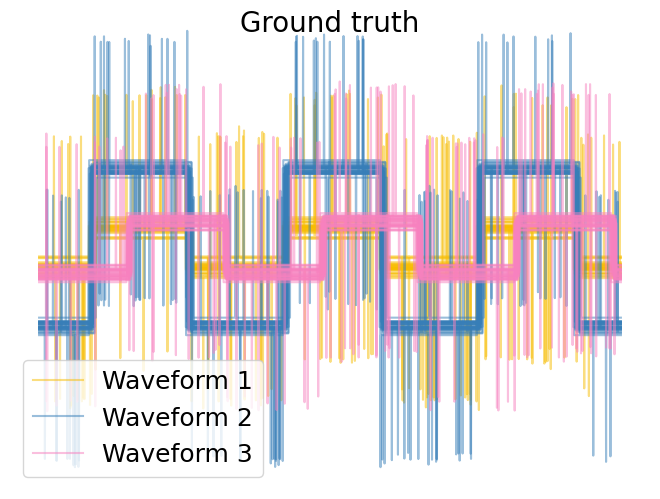

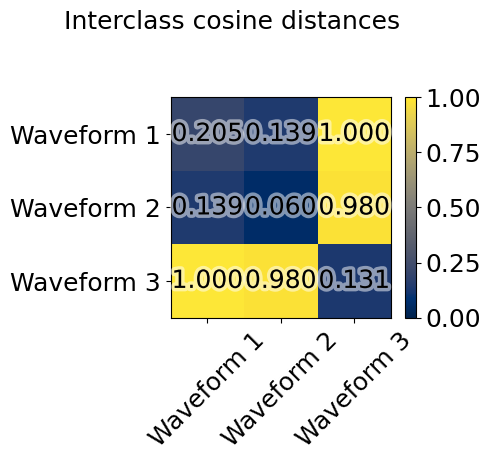

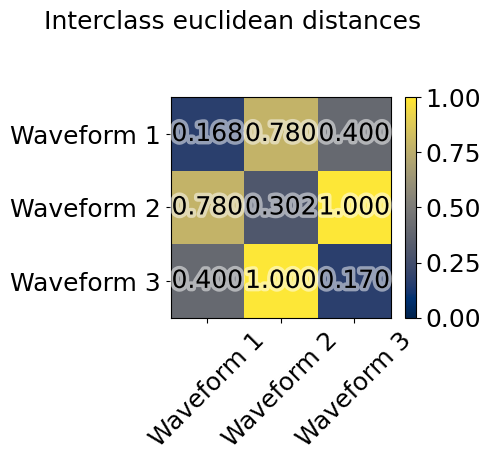

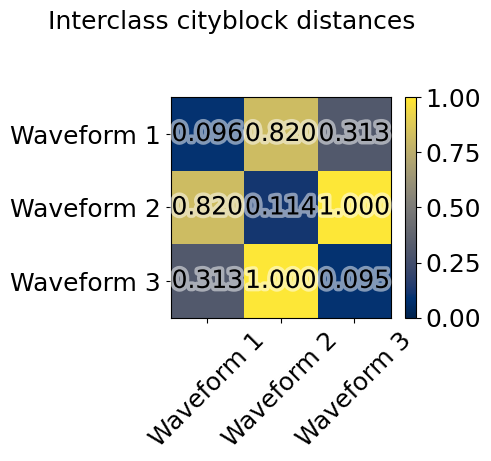

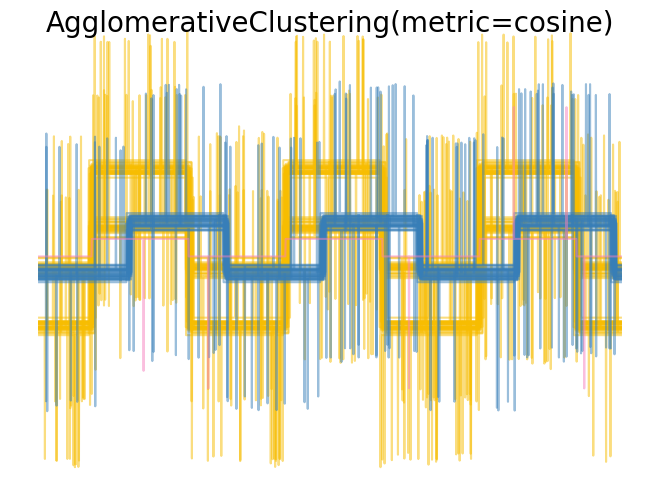

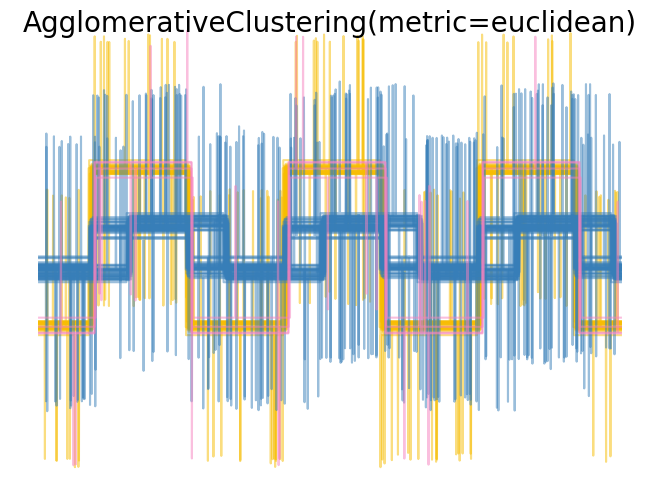

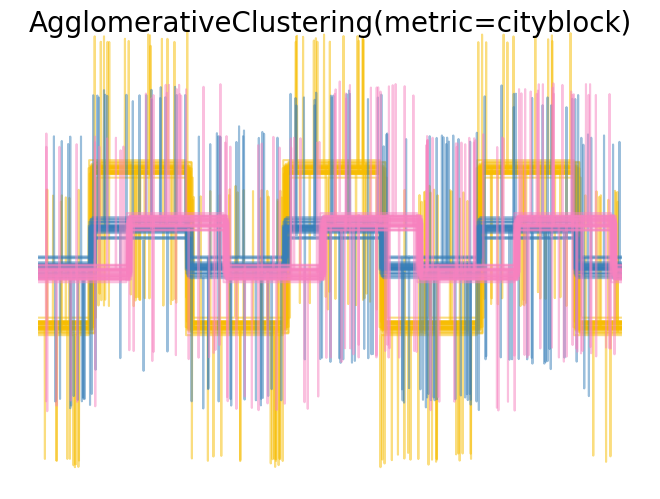

In [ ]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.patheffects as PathEffects
import matplotlib.pyplot as plt
import numpy as np

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import pairwise_distances

np.random.seed(0)

# Generate waveform data
n_features = 2000
t = np.pi * np.linspace(0, 1, n_features)


def sqr(x):
    return np.sign(np.cos(x))


X = list()
y = list()
for i, (phi, a) in enumerate([(0.5, 0.15), (0.5, 0.6), (0.3, 0.2)]):
    for _ in range(30):
        phase_noise = 0.01 * np.random.normal()
        amplitude_noise = 0.04 * np.random.normal()
        additional_noise = 1 - 2 * np.random.rand(n_features)
        # Make the noise sparse
        additional_noise[np.abs(additional_noise) < 0.997] = 0

        X.append(
            12
            * (
                (a + amplitude_noise) * (sqr(6 * (t + phi + phase_noise)))
                + additional_noise
            )
        )
        y.append(i)

X = np.array(X)
y = np.array(y)

n_clusters = 3

labels = ("Waveform 1", "Waveform 2", "Waveform 3")

colors = ["#f7bd01", "#377eb8", "#f781bf"]

# Plot the ground-truth labelling
plt.figure()
plt.axes([0, 0, 1, 1])
for l, color, n in zip(range(n_clusters), colors, labels):
    lines = plt.plot(X[y == l].T, c=color, alpha=0.5)
    lines[0].set_label(n)

plt.legend(loc="best")

plt.axis("tight")
plt.axis("off")
plt.suptitle("Ground truth", size=20, y=1)


# Plot the distances
for index, metric in enumerate(["cosine", "euclidean", "cityblock"]):
    avg_dist = np.zeros((n_clusters, n_clusters))
    plt.figure(figsize=(5, 4.5))
    for i in range(n_clusters):
        for j in range(n_clusters):
            avg_dist[i, j] = pairwise_distances(
                X[y == i], X[y == j], metric=metric
            ).mean()
    avg_dist /= avg_dist.max()
    for i in range(n_clusters):
        for j in range(n_clusters):
            t = plt.text(
                i,
                j,
                "%5.3f" % avg_dist[i, j],
                verticalalignment="center",
                horizontalalignment="center",
            )
            t.set_path_effects(
                [PathEffects.withStroke(linewidth=5, foreground="w", alpha=0.5)]
            )

    plt.imshow(avg_dist, interpolation="nearest", cmap="cividis", vmin=0)
    plt.xticks(range(n_clusters), labels, rotation=45)
    plt.yticks(range(n_clusters), labels)
    plt.colorbar()
    plt.suptitle("Interclass %s distances" % metric, size=18, y=1)
    plt.tight_layout()


# Plot clustering results
for index, metric in enumerate(["cosine", "euclidean", "cityblock"]):
    model = AgglomerativeClustering(
        n_clusters=n_clusters, linkage="average", metric=metric
    )
    model.fit(X)
    plt.figure()
    plt.axes([0, 0, 1, 1])
    for l, color in zip(np.arange(model.n_clusters), colors):
        plt.plot(X[model.labels_ == l].T, c=color, alpha=0.5)
    plt.axis("tight")
    plt.axis("off")
    plt.suptitle("AgglomerativeClustering(metric=%s)" % metric, size=20, y=1)


plt.show()